# Projeto 1 - Airbnb: características do imóvel e valor da diária

**Autores:**
- Anna Albuquerque
- Mateus Cortez Camacho

- id: Unique identifier for each listing - Identificação
- name: Name of the Airbnb listing - Qualitativa Nominal
- rating: Average rating of the listing - Quantitativa Contínua
- reviews: Number of reviews received - Quantitativa Discreta
- host_name: Name of the host - Qualitativa Nominal
- host_id: Unique identifier for the host - Identificação
- address: Location of the listing (city, region, country) - Qualitativa Nominal
- features: Summary of features (number of guests, bedrooms, beds, bathrooms) - Qualitativa Nominal
- amenities: List of amenities provided - Qualitativa Nominal 
- price: Price per night in the local currency - Quantitativa (???)
- country: Country where the listing is located - Qualitativa Nominal
- bathrooms: Number of bathrooms - Quantitativa Discreta
- beds: Number of beds - Quantitativa Discreta
- guests: Number of guests the listing can accommodate - Quantitativa Discreta
- toilets: Number of toilets - Quantitativa Discreta
- bedrooms: Number of bedrooms - Quantitativa Discreta
- studios: Number of studio units - Qualitativa Nominal
- checkin: Check-in time - Qualitativa Nominal
- checkout: Check-out time - Qualitativa Nominal

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('airbnb.csv')
df.head()

,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm


### Tamanho do DataFrame - 12805 linhas e 23 Colunas

In [14]:
df.shape

#12805 linhas e 23 Colunas

(12805, 23)

### Code de Variáveis - Apenas os de checkin(out) estão errados em string

In [5]:
df.dtypes

Unnamed: 0        int64
id                int64
name                str
rating              str
reviews             str
host_name           str
host_id         float64
address             str
features            str
amenities           str
safety_rules        str
hourse_rules        str
img_links           str
price             int64
country             str
bathrooms         int64
beds              int64
guests            int64
toiles            int64
bedrooms          int64
studios           int64
checkin             str
checkout            str
dtype: object

### Contagem de NaNs

In [15]:

# conta os NaNs por coluna e calcula o percentual
nulos = df.isna().sum()
percentual = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'qtd_nulos': nulos,
    'percentual (%)': percentual
}).sort_values('qtd_nulos', ascending=False)

print(resumo_nulos)

#Muitos Valores não preenchidos em Checkout e Checkin

              qtd_nulos  percentual (%)
checkout           2450           19.13
checkin             800            6.25
host_name             8            0.06
name                  0            0.00
rating                0            0.00
id                    0            0.00
Unnamed: 0            0            0.00
host_id               0            0.00
reviews               0            0.00
address               0            0.00
features              0            0.00
hourse_rules          0            0.00
img_links             0            0.00
amenities             0            0.00
safety_rules          0            0.00
country               0            0.00
price                 0            0.00
bathrooms             0            0.00
beds                  0            0.00
toiles                0            0.00
guests                0            0.00
studios               0            0.00
bedrooms              0            0.00


### Contagem de Valores

In [25]:
colunas_categoricas = ['country', 'bathrooms', 'bedrooms', 'beds', 'guests', 'studios']

for col in colunas_categoricas:
    print(f"\n{'='*40}")
    print(f"Variável: {col}")
    print('='*40)
    print(df[col].value_counts().head(8))


#Depois dar uma verificada se tem nomes de países escritos de maneira alternativa e centralizar tudo


Variável: country
country
India       2766
Italy       1186
Greece       885
Thailand     677
Turkey       519
France       466
Morocco      375
Georgia      368
Name: count, dtype: int64

Variável: bathrooms
bathrooms
1    8000
2    1917
3     902
4     590
0     446
5     306
6     215
8     121
Name: count, dtype: int64

Variável: bedrooms
bedrooms
1    6374
2    2377
3    1406
4     772
0     692
5     420
6     251
7     135
Name: count, dtype: int64

Variável: beds
beds
1    3972
2    2981
3    1781
4    1283
5     701
6     517
0     277
8     270
Name: count, dtype: int64

Variável: guests
guests
2     3729
4     2607
6     1471
3     1228
8      732
5      702
16     640
10     457
Name: count, dtype: int64

Variável: studios
studios
0    12503
1      302
Name: count, dtype: int64


### Gráficos de Barra das Quantidades - Tudo OK

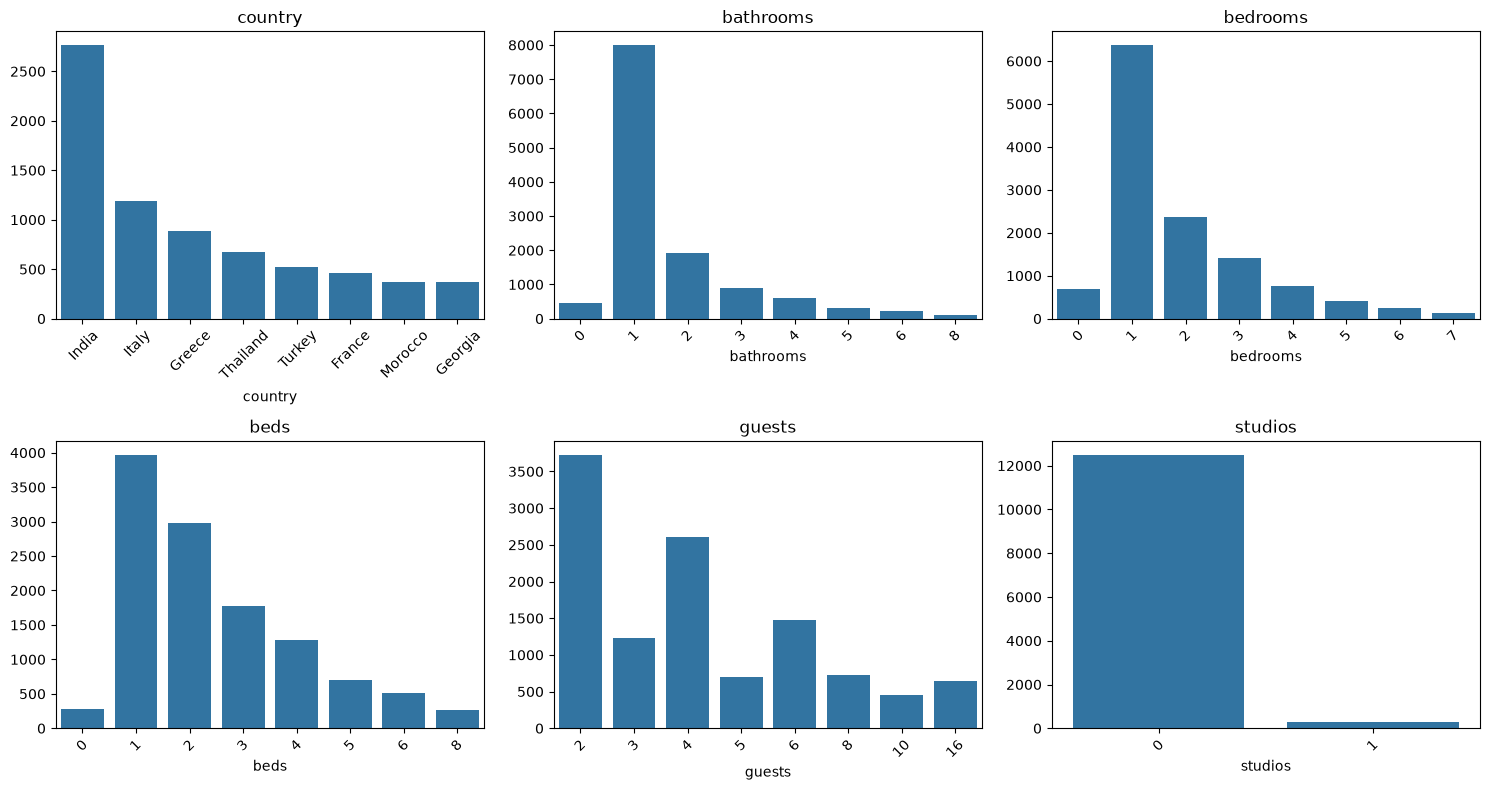

In [13]:
colunas_categoricas = ['country', 'bathrooms', 'bedrooms', 'beds', 'guests', 'studios']

n_cols = 3
n_rows = math.ceil(len(colunas_categoricas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    contagem = df[col].value_counts().head(8)
    sns.barplot(x=contagem.index, y=contagem.values, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# remove eixos vazios se sobrarem
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Duplicatas - Tudo Ok

In [ ]:
df['id'].duplicated() 
print("Existem:",df['id'].duplicated().sum(),"valores duplicados na coluna id")

df['host_id'].duplicated() 
print("\nExistem:",df['host_id'].duplicated().sum(),"valores duplicados na coluna host_id")
df['host_name'].duplicated() 
print("Existem:",df['host_name'].duplicated().sum(),"valores duplicados na coluna host_name") #Justo ser diferente de host_id, pois eles podem ter apenas nomes iguais

Existem: 0 valores duplicados na coluna id

Existem: 2430 valores duplicados na coluna host_id
Existem: 5967 valores duplicados na coluna host_name


### Verificação de Outliers

In [47]:
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

for col in colunas_quant_disc:
    print(f"\n{'='*40}")
    print(f"Variável: {col}")
    print('='*40)
    print(df[col].describe())




Variável: bathrooms
count    12805.000000
mean         1.874424
std          2.091399
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         50.000000
Name: bathrooms, dtype: float64

Variável: bedrooms
count    12805.000000
mean         2.136041
std          2.359005
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         50.000000
Name: bedrooms, dtype: float64

Variável: beds
count    12805.000000
mean         3.316751
std          4.037791
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         98.000000
Name: beds, dtype: float64

Variável: guests
count    12805.000000
mean         5.213745
std          3.808830
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         16.000000
Name: guests, dtype: float64


### Boxplots pra verificação de outliers

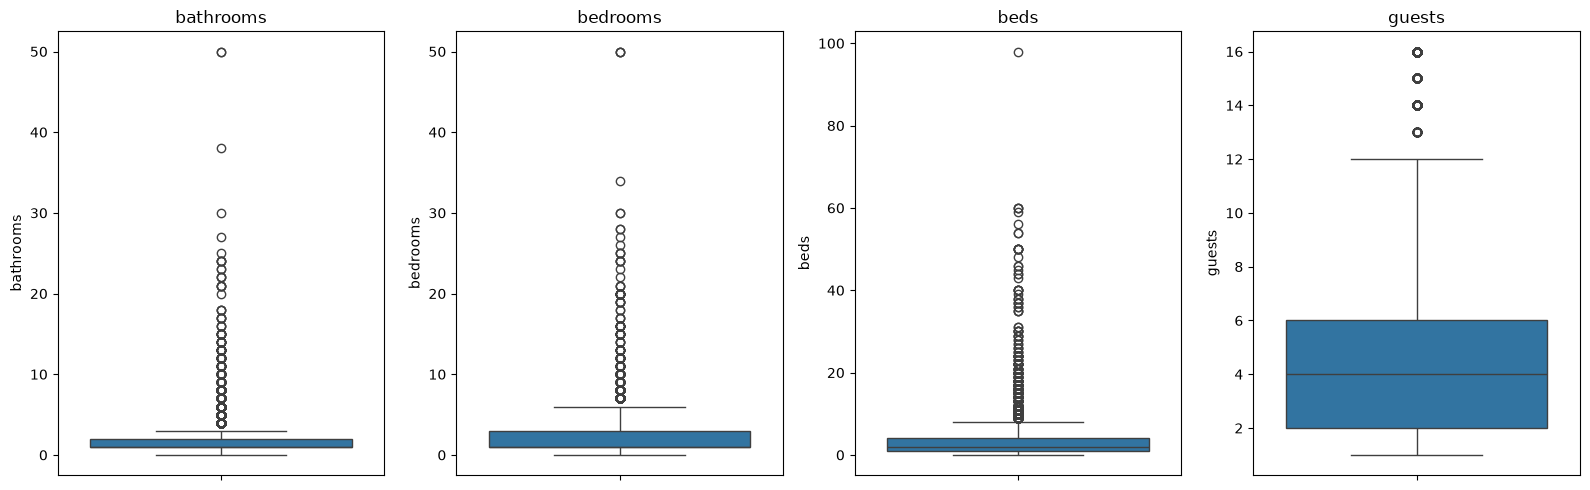

In [49]:
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

fig, axes = plt.subplots(1, len(colunas_quant_disc), figsize=(16, 5))

for i, col in enumerate(colunas_quant_disc):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#Guests faz sentido os outliers, mas o resto achp que dá pra remover

### Análise Interquartílica

In [ ]:
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

for col in colunas_quant_disc:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    pct_outliers = n_outliers / len(df) * 100
    
    print(f"\n{'='*40}")
    print(f"Variável: {col}")
    print('='*40)
    print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
    print(f"Limite inferior: {lim_inf} | Limite superior: {lim_sup}")
    print(f"Outliers: {n_outliers} ({pct_outliers:.2f}%)")



Variável: bathrooms
Q1: 1.0 | Q3: 2.0 | IQR: 1.0
Limite inferior: -0.5 | Limite superior: 3.5
Outliers: 1540 (12.03%)

Variável: bedrooms
Q1: 1.0 | Q3: 3.0 | IQR: 2.0
Limite inferior: -2.0 | Limite superior: 6.0
Outliers: 513 (4.01%)

Variável: beds
Q1: 1.0 | Q3: 4.0 | IQR: 3.0
Limite inferior: -3.5 | Limite superior: 8.5
Outliers: 770 (6.01%)

Variável: guests
Q1: 2.0 | Q3: 6.0 | IQR: 4.0
Limite inferior: -4.0 | Limite superior: 12.0
Outliers: 921 (7.19%)


Todos tem bastante outliers, será que vale a pena tirar tudo?
Por enquanto, vou tirar só os que estão acima de 30

### Remoção dos Outliers Acima de 30

Linhas originais: 12805
Linhas removidas: 42
Linhas restantes: 12763


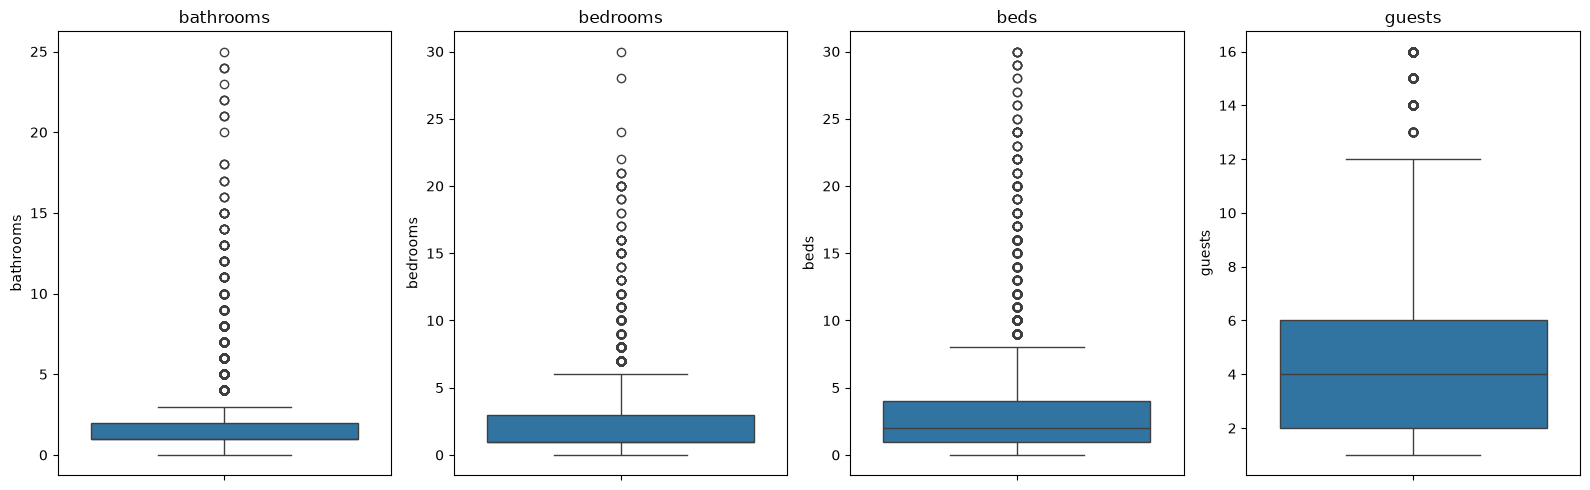

In [59]:
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

mask = pd.Series(True, index=df.index)
for col in colunas_quant_disc:
    mask &= (df[col] <= 30)

print(f"Linhas originais: {len(df)}")
print(f"Linhas removidas: {(~mask).sum()}")
print(f"Linhas restantes: {mask.sum()}")

df = df[mask].copy()

#Boxplot
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

fig, axes = plt.subplots(1, len(colunas_quant_disc), figsize=(16, 5))

for i, col in enumerate(colunas_quant_disc):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Matriz de Correlações

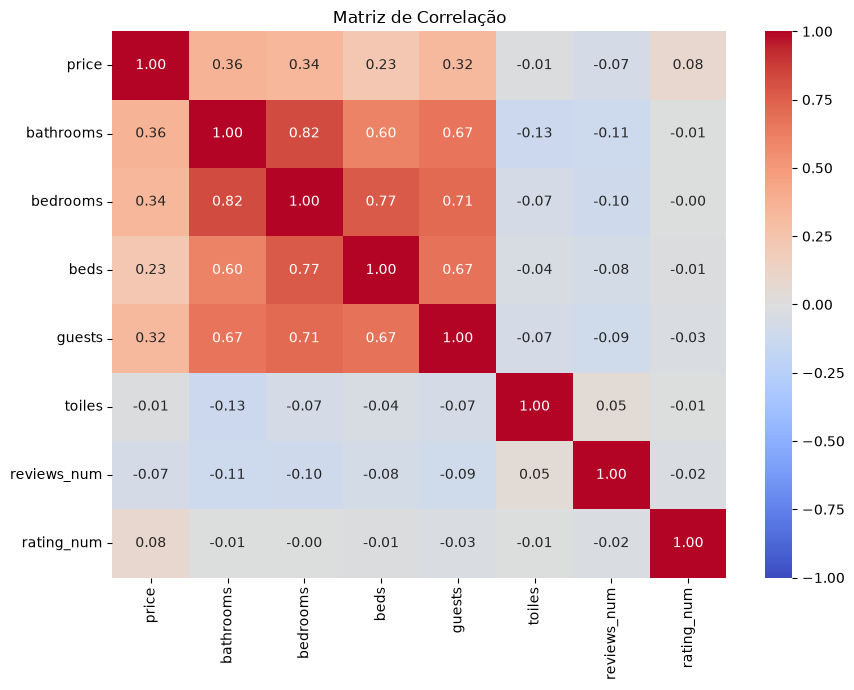

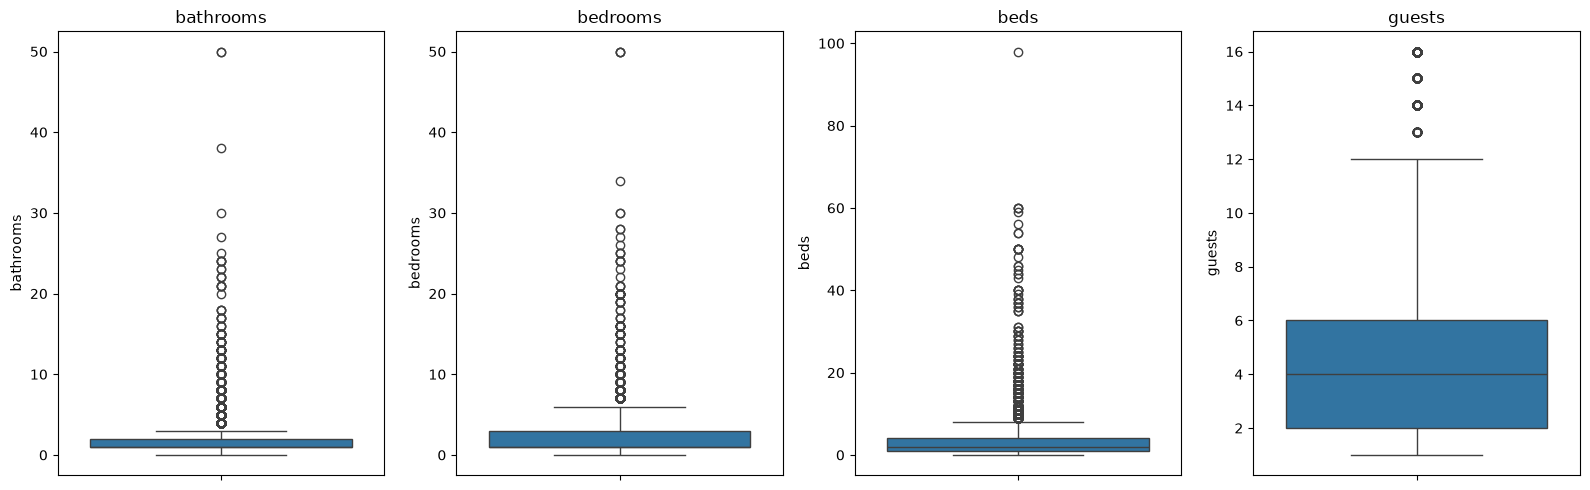

In [ ]:


# limpar rating e reviews antes (ainda estão como texto)
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')  # "New" vira NaN
df['reviews_num'] = pd.to_numeric(df['reviews'], errors='coerce')

colunas = ['price', 'bathrooms', 'bedrooms', 'beds', 'guests', 
                          'toiles', 'reviews_num', 'rating_num']

corr = df[colunas].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

#Acho que da pra cortar de toiles até rating_num

### Limpeza dos dados

In [33]:
#errados: não consigo comparar objetos --> transformar para números
#rating           object

#reviews          object

#possivelmente errados: talvez fosse bom mudar para a data, mas não sei se vale muito na avaliação
#checkin          object


#checkout         object